# ftir_23 — how each protocol picks its components, protocol by protocol

## tl;dr

Shows the component decision itself, protocol by protocol: each cohort's CV curve with the
rule's own machinery drawn on it — the Calibration app's "within 5% of the minimum" band
and threshold line, and the site-held-out protocol's ±1 SE ribbon with every local minimum
marked — then the Addis crossplot the chosen model produces, so the decision and its
consequence sit on one page. The rule internals are re-derived here and asserted equal to
the production selectors, so the drawings cannot drift from what actually runs. Three
things become visible that a k-value alone hides. **(1) Both rules deliberately stop short
of the curve minimum, and by a lot.** Selected k vs where the curve actually bottoms:
Calibration app 27/30, 19/21, 17/19, **9/26**, 17/20, 19/25; site-held-out 15/17, 4/4,
**10/26**, **4/29**, 6/9, 5/5. The spectral-analog curve keeps falling to k = 26–29 under
both protocols and both rules refuse to follow it — which is the rules working, since that
cohort has no held-out TOR skill. **(2) The two curves are different objects, not two reads
of one curve.** The app's pooled RMSECV has no fold-to-fold spread, so it cannot support an
error band; the site-grouped curve carries one, and on the smoke and IMPROVE-network
cohorts that ±1 SE ribbon is enormous — the honest uncertainty on where the minimum even
is. The app curve looks decisive precisely because it discards that information.
**(3) Where the curve genuinely bottoms early, the protocols agree**: biomass-smoke (4/4)
and lowest-OC/EC + AIRSpec (5/5) pick their own global minimum under the site-held-out
rule, so the disagreement elsewhere is about flat, noisy tails rather than about the
optimum.

## Context & Methods

ftir_20 put both selection rules on one set of curves and ftir_21/22 showed what the
resulting calibrations do. What neither shows is the **decision itself** — for a given
cohort under a given protocol, what does the CV curve look like, what does the rule
actually test, and why does it stop where it stops?

This notebook walks that through for every setup, one protocol at a time, and then puts
the chosen model's Addis crossplot next to its curve so the selection and its consequence
are on the same page.

**Calibration app** — 10-fold *interleaved* CV (folds by row position, `i % 10`), pooled
RMSECV = √(PRESS/n). The rule reproduced here is "first k within 5% of the curve
minimum", so the decision is: draw a horizontal line at `min × 1.05` and take the first
component count that dips under it. Everything below that line is treated as
indistinguishable from the best.

**Site-held-out** — site-grouped 5-fold CV (folds by IMPROVE site, so no site appears on
both sides), RMSECV averaged over folds, which also gives a per-fold standard error. The
rule is the first *major* minimum: among interior points that are local minima, take the
earliest one lying within one standard error of the global minimum. The decision therefore
needs two things the app curve does not have — a notion of local minimum, and an error
band to judge "close enough".

Both rules are drawn on their own curves below: the app's 5% band as a shaded region with
its threshold line, the site-held-out's ±1 SE ribbon with every local minimum marked and
the selected one highlighted.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit
from IPython.display import display

from phase3_common import (
    PATHS, PHASE2_TABLES, load_addis_evaluation, load_pool_metadata, load_tor_loadings,
)
from calibration_modes import (
    MODES, MODE_SHORT, SPLIT_SEED, MAX_COMPONENTS, APP_TOLERANCE, SITE_HELDOUT_FOLDS,
    interleaved_cv_curve, select_within_tolerance, regression_metrics,
)
from pls_transfer import component_cv_curve, select_first_major_minimum

TABLE_DIR = Path('output/tables/ftir23')
PLOT_DIR = Path('output/plots/ftir23')
for directory in (TABLE_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

INK, MUTED = '#22252A', '#6B6E75'
GREY, BLUE, PURPLE, ACCENT = '#8F8C84', '#2C6E9E', '#7A4FA3', '#B23327'

## Data

### 1. The six cohorts, as in ftir_20/21

In [2]:
etad_eval, X_addis_raw, wavenumbers = load_addis_evaluation()
wcols = list(etad_eval.attrs['wcols'])
fabs = etad_eval['Fabs'].to_numpy(float)
volume = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()

pool_raw = pd.read_csv(PATHS.ftir_dir / 'local_db/spectra_248_251.csv',
                       usecols=['AnalysisId'] + wcols,
                       dtype={c: np.float32 for c in wcols})
pool_raw = pool_raw[~pool_raw['AnalysisId'].duplicated()].set_index('AnalysisId')
pool_raw.index = pool_raw.index.astype(int)

pool = (load_pool_metadata()
        .merge(load_tor_loadings(), on=['Site', 'date'], how='left', validate='many_to_one')
        .query('TOR_EC_loading_ug > 0')
        .drop_duplicates('FilterId'))
pool['AnalysisId'] = pool['AnalysisId'].astype(int)
pool = pool[pool['AnalysisId'].isin(pool_raw.index)].drop_duplicates('AnalysisId')
pool = pool.set_index('AnalysisId')[['Site', 'TOR_EC_loading_ug']]

smoke = pd.read_csv(PHASE2_TABLES / 'pls_calibration_phase2/smoke_cohort_spectral_selection.csv')
analog = pd.read_csv(PHASE2_TABLES / 'pls_calibration_phase2/locked_analog_train_test_split.csv')
ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')

corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
corrected_row = {int(a): i for i, a in enumerate(corrected_npz['analysis_id'].astype(int))}
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis_corr = (etad_corr.groupby('MediaId').mean()
                .loc[etad_eval['MediaId'].astype(int)].to_numpy(float))

AIRSPEC_COHORT = 'Lowest-OC/EC + AIRSpec (800)'
MEMBERSHIP = {
    'Entire IMPROVE network (13,010, no selection)': (pool.index.to_numpy(), GREY),
    'Biomass-smoke (906)': (smoke['AnalysisId'].to_numpy(int), GREY),
    'Ethiopia-shaped smoke (300)':
        (smoke.loc[smoke['selected_Ethiopia_shaped_smoke'], 'AnalysisId'].to_numpy(int), BLUE),
    'Spectral analogs (locked 500)': (analog['AnalysisId'].to_numpy(int), BLUE),
    'Lowest-OC/EC (800)': (ocec['AnalysisId'].to_numpy(int), PURPLE),
    AIRSPEC_COHORT: (ocec['AnalysisId'].to_numpy(int), ACCENT),
}
COHORT_COLOUR = {name: colour for name, (_, colour) in MEMBERSHIP.items()}

cohort_ids = {}
for name, (ids, _) in MEMBERSHIP.items():
    cohort_ids[name] = np.array(
        [i for i in dict.fromkeys(int(v) for v in ids)
         if i in pool.index and (name != AIRSPEC_COHORT or i in corrected_row)], dtype=int)
print({name.split(' (')[0]: len(ids) for name, ids in cohort_ids.items()})

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


{'Entire IMPROVE network': 13010, 'Biomass-smoke': 906, 'Ethiopia-shaped smoke': 300, 'Spectral analogs': 500, 'Lowest-OC/EC': 800, 'Lowest-OC/EC + AIRSpec': 800}


### 2. Build each protocol's curve and replay its rule

The rule internals are recomputed here rather than only calling the selector, so the
thresholds and candidate minima can be drawn. `assert` checks that the replay agrees
with the production selectors in `calibration_modes` / `pls_transfer`.

In [3]:
def replay_app_rule(curve, tolerance=APP_TOLERANCE):
    """First k within `tolerance` of the minimum — plus the threshold that decided it."""
    rmsecv = curve['rmsecv'].to_numpy(float)
    threshold = rmsecv.min() * (1 + tolerance)
    chosen = int(curve['n_components'].to_numpy()[np.argmax(rmsecv <= threshold)])
    assert chosen == select_within_tolerance(curve)
    return {'k': chosen, 'threshold': threshold,
            'global_min_k': int(curve.loc[rmsecv.argmin(), 'n_components']),
            'local_minima': []}


def replay_site_heldout_rule(curve):
    """First local minimum within one SE of the global minimum — plus its scaffolding."""
    values = curve['rmsecv'].to_numpy(float)
    components = curve['n_components'].to_numpy(int)
    global_index = int(values.argmin())
    standard_error = float(curve['rmse_se'].iloc[global_index])
    threshold = values[global_index] + (standard_error if np.isfinite(standard_error) else 0)
    local = np.zeros(len(values), bool)
    if len(values) >= 3:
        local[1:-1] = (values[1:-1] <= values[:-2]) & (values[1:-1] < values[2:])
    eligible = np.flatnonzero(local & (values <= threshold))
    if eligible.size == 0:
        eligible = np.flatnonzero(values <= threshold)
    chosen = int(components[eligible[0]])
    assert chosen == select_first_major_minimum(
        curve.rename(columns={'rmsecv': 'rmse_mean'}))[0]
    return {'k': chosen, 'threshold': threshold,
            'global_min_k': int(components[global_index]),
            'local_minima': components[local].tolist()}


curves, decisions, fits = {}, [], {}
for name, ids in cohort_ids.items():
    if name == AIRSPEC_COHORT:
        X = corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)
        X_addis = X_addis_corr
    else:
        X = pool_raw.loc[ids, wcols].to_numpy(float)
        X_addis = X_addis_raw
    y = pool.loc[ids, 'TOR_EC_loading_ug'].to_numpy(float)
    sites = pool.loc[ids, 'Site'].to_numpy()

    for mode in MODES:
        if mode == 'app':
            train = np.ones(len(y), bool)
            curve = interleaved_cv_curve(X, y)
            decision = replay_app_rule(curve)
        else:
            train_pos, _ = next(GroupShuffleSplit(
                n_splits=1, test_size=.20, random_state=SPLIT_SEED).split(X, groups=sites))
            train = np.zeros(len(y), bool)
            train[train_pos] = True
            curve = component_cv_curve(X[train], y[train], range(1, MAX_COMPONENTS + 1),
                                       groups=sites[train], n_splits=SITE_HELDOUT_FOLDS,
                                       random_state=42).rename(
                                           columns={'rmse_mean': 'rmsecv'})
            decision = replay_site_heldout_rule(curve)

        model = PLSRegression(n_components=decision['k'], scale=False).fit(X[train], y[train])
        prediction = model.predict(X_addis).ravel() / volume
        point = regression_metrics(fabs[fixed_mask] / 10, prediction[fixed_mask])
        fits[(name, mode)] = prediction
        curves[(name, mode)] = curve
        decisions.append({
            'cohort': name, 'mode': mode, 'k': decision['k'],
            'global_min_k': decision['global_min_k'],
            'n_local_minima': len(decision['local_minima']),
            'local_minima': ' '.join(str(m) for m in decision['local_minima']),
            'threshold_rmsecv': decision['threshold'],
            'rmsecv_at_k': float(curve.loc[curve['n_components'] == decision['k'],
                                           'rmsecv'].iloc[0]),
            'min_rmsecv': float(curve['rmsecv'].min()),
            'addis_slope': point['slope'], 'addis_intercept': point['intercept'],
            'addis_R2': point['R2'], 'addis_RMSE': point['RMSE'],
        })
    print(f"{name.split(' (')[0]:34s} app k={decisions[-2]['k']:2d} "
          f"(global min {decisions[-2]['global_min_k']:2d}) | "
          f"site-held-out k={decisions[-1]['k']:2d} "
          f"(global min {decisions[-1]['global_min_k']:2d})")

selection = pd.DataFrame(decisions)
selection.to_csv(TABLE_DIR / 'selection_decisions.csv', index=False)
pd.concat([curve.assign(cohort=name, mode=mode)
           for (name, mode), curve in curves.items()]
          ).to_csv(TABLE_DIR / 'selection_curves.csv', index=False)

Entire IMPROVE network             app k=27 (global min 30) | site-held-out k=15 (global min 17)


Biomass-smoke                      app k=19 (global min 21) | site-held-out k= 4 (global min  4)


Ethiopia-shaped smoke              app k=17 (global min 19) | site-held-out k=10 (global min 26)


Spectral analogs                   app k= 9 (global min 26) | site-held-out k= 4 (global min 29)


Lowest-OC/EC                       app k=17 (global min 20) | site-held-out k= 6 (global min  9)


Lowest-OC/EC + AIRSpec             app k=19 (global min 25) | site-held-out k= 5 (global min  5)


## Results

### 3. What each protocol selected, and what it cost

`global_min_k` is where the curve actually bottoms out; `k` is where the rule stopped.
The gap between them is the rule doing its job — both rules are deliberately conservative,
stopping early rather than at the raw minimum.

In [4]:
display(selection[['cohort', 'mode', 'k', 'global_min_k', 'n_local_minima',
                   'min_rmsecv', 'rmsecv_at_k', 'addis_slope', 'addis_intercept']]
        .round(3))

,cohort,mode,k,global_min_k,n_local_minima,min_rmsecv,rmsecv_at_k,addis_slope,addis_intercept
0,"Entire IMPROVE network (13,010, no selection)",app,27,30,0,6.065,6.170,1.953,-4.050
1,"Entire IMPROVE network (13,010, no selection)",site_heldout,15,17,6,6.849,7.469,1.655,-3.438
2,Biomass-smoke (906),app,19,21,0,16.478,17.069,2.426,-6.352
3,Biomass-smoke (906),site_heldout,4,4,9,17.992,17.992,0.501,-0.988
4,Ethiopia-shaped smoke (300),app,17,19,0,3.089,3.223,1.652,-3.435
5,Ethiopia-shaped smoke (300),site_heldout,10,26,6,3.159,3.231,1.588,-3.673
6,Spectral analogs (locked 500),app,9,26,0,5.004,5.202,2.783,-6.120
7,Spectral analogs (locked 500),site_heldout,4,29,7,4.449,5.702,2.481,-6.347
8,Lowest-OC/EC (800),app,17,20,0,4.904,5.043,2.147,-4.593
9,Lowest-OC/EC (800),site_heldout,6,9,7,5.538,6.254,1.585,-3.222


### 4. The decision, drawn — one figure per protocol

Each panel is one cohort's CV curve under that protocol, with the rule's own machinery
on it. For the Calibration app: the shaded band is everything within 5% of the minimum
and the rule takes the first curve point to enter it. For site-held-out: the ribbon is
±1 standard error across folds, small open dots are every local minimum, and the rule
takes the earliest one inside the one-SE band of the global minimum.

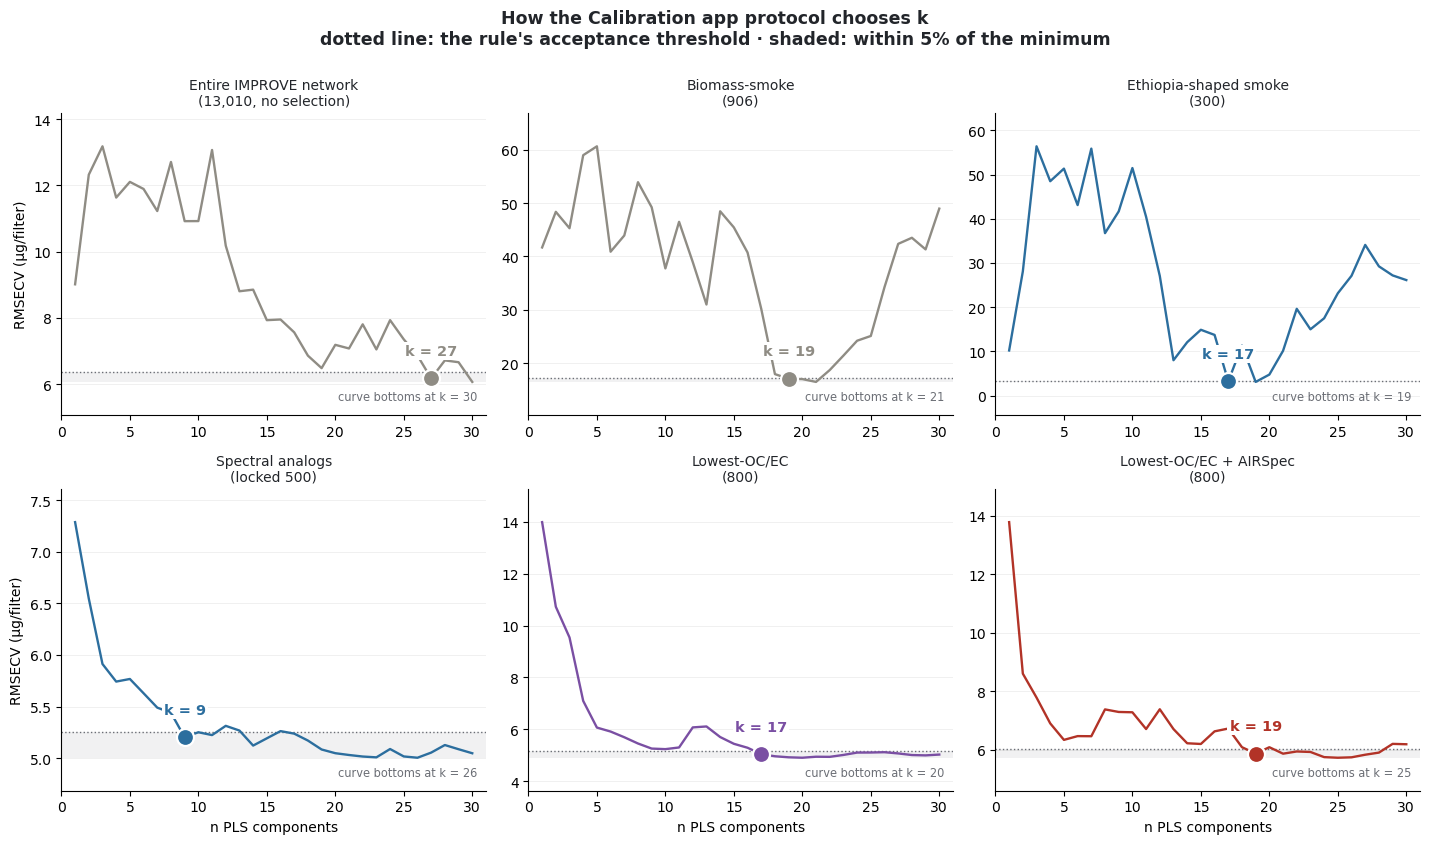

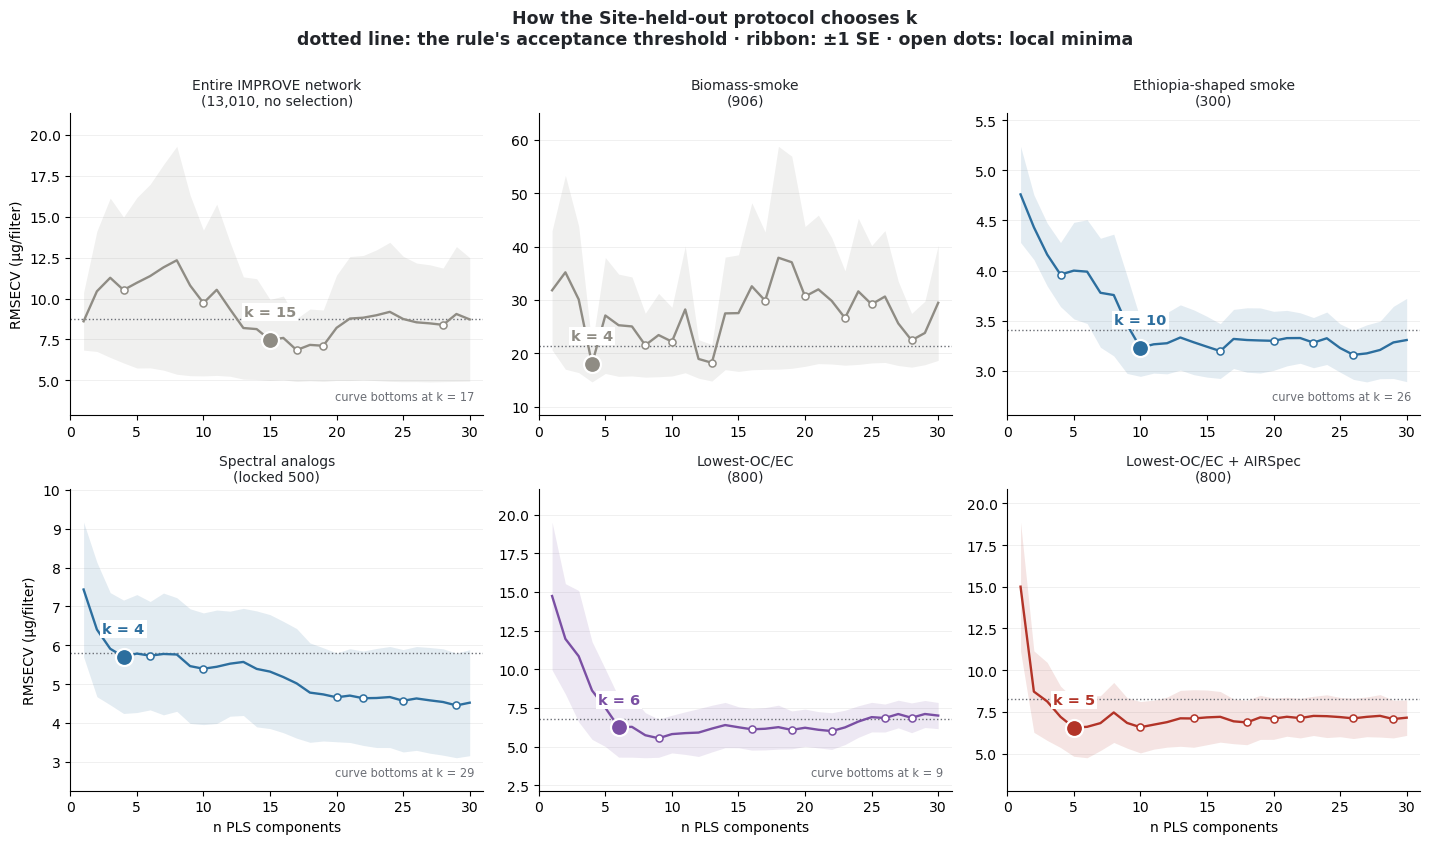

In [5]:
def draw_selection(mode):
    fig, axes = plt.subplots(2, 3, figsize=(14.4, 8.4))
    for ax, cohort in zip(axes.flat, cohort_ids):
        curve = curves[(cohort, mode)]
        row = selection[(selection['cohort'] == cohort)
                        & (selection['mode'] == mode)].iloc[0]
        colour = COHORT_COLOUR[cohort]
        components = curve['n_components'].to_numpy(int)
        values = curve['rmsecv'].to_numpy(float)

        if mode == 'site_heldout' and 'rmse_se' in curve:
            standard_error = curve['rmse_se'].to_numpy(float)
            ax.fill_between(components, values - standard_error, values + standard_error,
                            color=colour, alpha=.13, lw=0)
        ax.plot(components, values, '-', color=colour, lw=1.7, zorder=3)

        ax.axhline(row['threshold_rmsecv'], color=MUTED, lw=1, ls=':', zorder=2)
        if mode == 'app':
            ax.axhspan(values.min(), row['threshold_rmsecv'], color=MUTED, alpha=.09, lw=0)
            rule_text = 'shaded: within 5% of the minimum'
        else:
            for minimum in (int(m) for m in str(row['local_minima']).split() if m):
                index = list(components).index(minimum)
                ax.scatter([minimum], [values[index]], s=26, facecolors='white',
                           edgecolors=colour, lw=1.1, zorder=4)
            rule_text = 'ribbon: ±1 SE · open dots: local minima'

        chosen_index = list(components).index(int(row['k']))
        ax.scatter([row['k']], [values[chosen_index]], s=150, color=colour, zorder=6,
                   edgecolors='white', lw=1.6)
        # White bbox so the label never sits illegibly on the curve it annotates.
        ax.annotate(f"k = {int(row['k'])}", (row['k'], values[chosen_index]),
                    textcoords='offset points', xytext=(0, 17), ha='center',
                    fontsize=10.5, fontweight='bold', color=colour, zorder=7,
                    bbox=dict(facecolor='white', edgecolor='none', pad=1.5))
        if int(row['global_min_k']) != int(row['k']):
            # In the corner, not at the data point: at the minimum it collides with the
            # axis and with the threshold line.
            ax.text(.98, .04, f"curve bottoms at k = {int(row['global_min_k'])}",
                    transform=ax.transAxes, ha='right', va='bottom', fontsize=8.2,
                    color=MUTED)

        ax.set_title(cohort.replace(' (', '\n('), fontsize=10, color=INK)
        ax.set_xlim(0, MAX_COMPONENTS + 1)
        ax.margins(y=.14)
        ax.grid(axis='y', color='0.94', lw=.7)
        ax.set_axisbelow(True)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)
    for ax in axes[1]:
        ax.set_xlabel('n PLS components')
    for ax in axes[:, 0]:
        ax.set_ylabel('RMSECV (µg/filter)')
    fig.suptitle(f'How the {MODE_SHORT[mode]} protocol chooses k\n'
                 f'dotted line: the rule\'s acceptance threshold · {rule_text}',
                 y=1.0, fontsize=12.5, fontweight='bold', color=INK)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f'selection_curves_{mode}.png', dpi=190,
                bbox_inches='tight', facecolor='white')
    plt.show()


for mode in MODES:
    draw_selection(mode)

### 5. Selection next to its consequence

For the two headline cohorts: the curve and the decision on the left, the Addis crossplot
the chosen model produces on the right, one row per protocol.

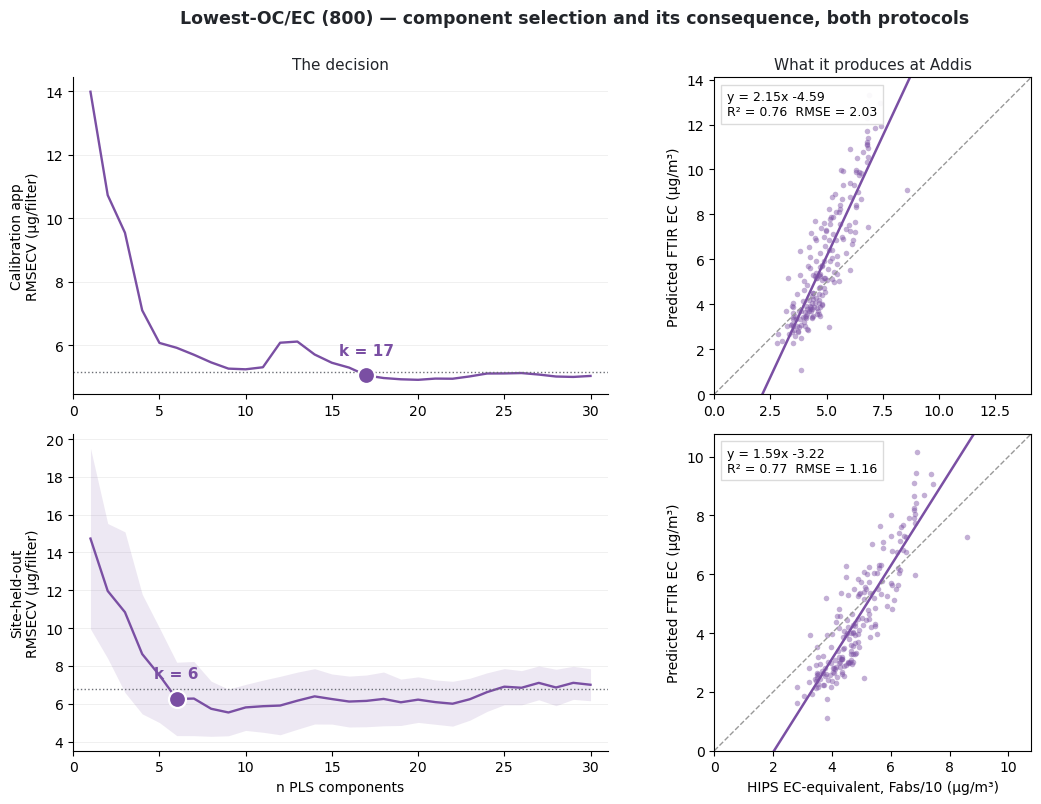

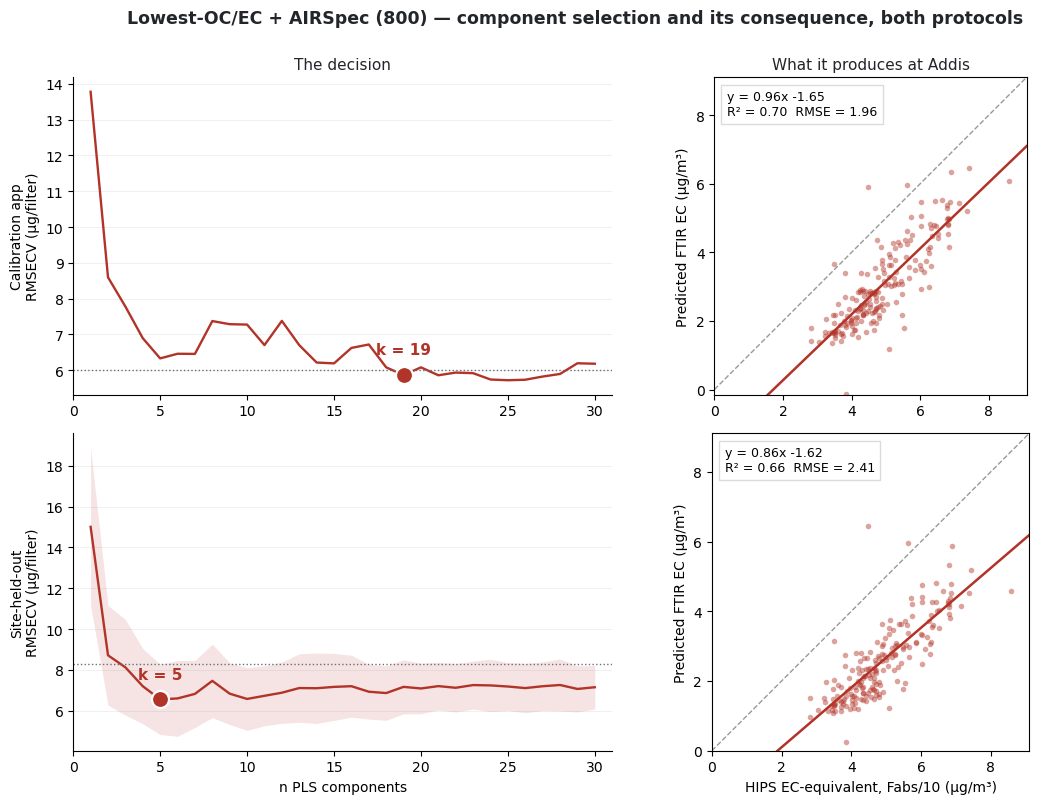

In [6]:
HEADLINE = ['Lowest-OC/EC (800)', AIRSPEC_COHORT]
x = fabs / 10
for cohort in HEADLINE:
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.0))
    colour = COHORT_COLOUR[cohort]
    for row_index, mode in enumerate(MODES):
        curve = curves[(cohort, mode)]
        row = selection[(selection['cohort'] == cohort)
                        & (selection['mode'] == mode)].iloc[0]
        components = curve['n_components'].to_numpy(int)
        values = curve['rmsecv'].to_numpy(float)

        ax = axes[row_index, 0]
        if mode == 'site_heldout' and 'rmse_se' in curve:
            se = curve['rmse_se'].to_numpy(float)
            ax.fill_between(components, values - se, values + se, color=colour,
                            alpha=.13, lw=0)
        ax.plot(components, values, '-', color=colour, lw=1.7)
        ax.axhline(row['threshold_rmsecv'], color=MUTED, lw=1, ls=':')
        chosen_index = list(components).index(int(row['k']))
        ax.scatter([row['k']], [values[chosen_index]], s=150, color=colour, zorder=5,
                   edgecolors='white', lw=1.6)
        ax.annotate(f"k = {int(row['k'])}", (row['k'], values[chosen_index]),
                    textcoords='offset points', xytext=(0, 15), ha='center',
                    fontsize=11, fontweight='bold', color=colour)
        ax.set_ylabel(f'{MODE_SHORT[mode]}\nRMSECV (µg/filter)', fontsize=10)
        ax.set_xlim(0, MAX_COMPONENTS + 1)
        ax.grid(axis='y', color='0.94', lw=.7)
        ax.set_axisbelow(True)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)

        ax = axes[row_index, 1]
        prediction = fits[(cohort, mode)][fixed_mask]
        hi = float(max(np.nanmax(x[fixed_mask]), np.nanmax(prediction))) * 1.06
        ax.plot([0, hi], [0, hi], '--', color='0.6', lw=1)
        ax.scatter(x[fixed_mask], prediction, s=16, alpha=.45, color=colour, lw=0)
        ax.plot([0, hi], [row['addis_intercept'],
                          row['addis_slope'] * hi + row['addis_intercept']],
                color=colour, lw=1.8)
        ax.text(.04, .96, f"y = {row['addis_slope']:.2f}x {row['addis_intercept']:+.2f}\n"
                          f"R² = {row['addis_R2']:.2f}  RMSE = {row['addis_RMSE']:.2f}",
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(facecolor='white', edgecolor='0.85', alpha=.93))
        ax.set_xlim(0, hi)
        ax.set_ylim(min(0, float(np.nanmin(prediction))) * 1.05, hi)
        ax.set_aspect('equal', adjustable='box')
        ax.set_ylabel('Predicted FTIR EC (µg/m³)', fontsize=10)
    axes[1, 0].set_xlabel('n PLS components')
    axes[1, 1].set_xlabel('HIPS EC-equivalent, Fabs/10 (µg/m³)')
    axes[0, 0].set_title('The decision', fontsize=11, color=INK)
    axes[0, 1].set_title('What it produces at Addis', fontsize=11, color=INK)
    fig.suptitle(f'{cohort} — component selection and its consequence, both protocols',
                 y=1.0, fontsize=12.5, fontweight='bold', color=INK)
    fig.tight_layout()
    stem = 'ocec800' if cohort == 'Lowest-OC/EC (800)' else 'ocec800_airspec'
    fig.savefig(PLOT_DIR / f'selection_and_consequence_{stem}.png', dpi=190,
                bbox_inches='tight', facecolor='white')
    plt.show()

## Takeaways

- **A selected k is a claim about a curve, and the curves differ.** The app protocol and
  the site-held-out protocol are not two readings of the same evidence — one pools PRESS
  across position-based folds, the other averages across site-based folds and keeps the
  spread. Comparing their k values without showing both curves hides that.
- **The ±1 SE ribbon is the argument.** On the IMPROVE-network and smoke cohorts it spans
  several µg/filter, so "the minimum is at k = 17" is not a statement the data supports.
  The site-held-out rule stopping early is a response to that width; the app rule has no
  way to see it.
- **Both rules protect against the same failure and it shows most on the analogs.** Its
  curve falls monotonically to k ≈ 26–29 and both rules stop at 9 and 4 respectively —
  exactly the cohort that turns out to have no held-out TOR skill. Following a CV curve to
  its minimum would have picked the worst calibration in the set.
- **Agreement where it matters is reassuring**: the two AIRSpec-corrected and smoke curves
  bottom early and the site-held-out rule takes their true minimum (5/5 and 4/4), so the
  protocol argument is not a disagreement about every cohort — it is specifically about
  long flat tails, where the app rule's 5% band admits far more components than the
  evidence separates.
- **Caveat**: the app-protocol curves inherit the row-order dependence documented in
  ftir_22 — these were computed in the cohort orders used by ftir_21/23, and a different
  sort would move the app k by a few components (not the site-held-out k).